<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
%pip install pandas matplotlib numpy scipy

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import re

# Define helper function for parsing age
def parse_age(age_str):
    """Parse age from various formats: '25-34', '24 years old', or direct numbers"""
    if pd.isna(age_str) or age_str == '':
        return None
    
    age_str = str(age_str).strip()
    
    # Handle "X years old" format
    if 'years old' in age_str:
        try:
            num = re.findall(r'\d+', age_str)
            if num:
                return float(num[0])
        except:
            return None
    
    # Handle "X-Y" range format
    if '-' in age_str and 'years' not in age_str:
        try:
            parts = age_str.split('-')
            low = float(parts[0].strip())
            high = float(parts[1].strip().replace('years old', '').strip())
            return (low + high) / 2
        except:
            return None
    
    # Try direct number conversion
    try:
        return float(age_str)
    except:
        return None


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




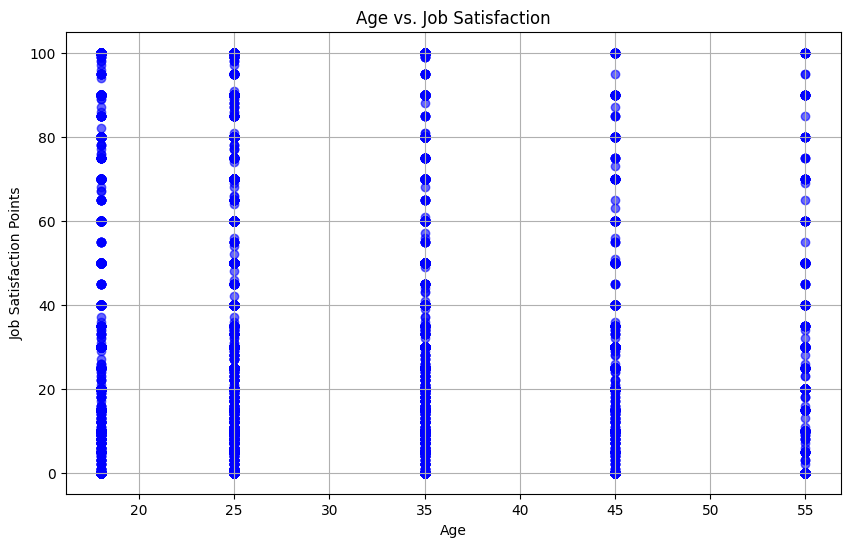

In [3]:
# Clean the data
df_clean = df[['Age', 'JobSatPoints_6']].dropna()

# Parse age values - handle various formats
def parse_age_inline(age_str):
    age_str = str(age_str).strip()
    if 'years old' in age_str:
        import re
        matches = re.findall(r'\d+', age_str)
        if matches:
            return float(matches[0])
    try:
        return float(age_str)
    except:
        return None

df_clean['Age_numeric'] = df_clean['Age'].apply(parse_age_inline)
df_clean = df_clean.dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Age_numeric'], df_clean['JobSatPoints_6'], alpha=0.6, color='blue')
plt.xlabel('Age')
plt.ylabel('Job Satisfaction Points')
plt.title('Age vs. Job Satisfaction')
plt.grid(True)
plt.show()


#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


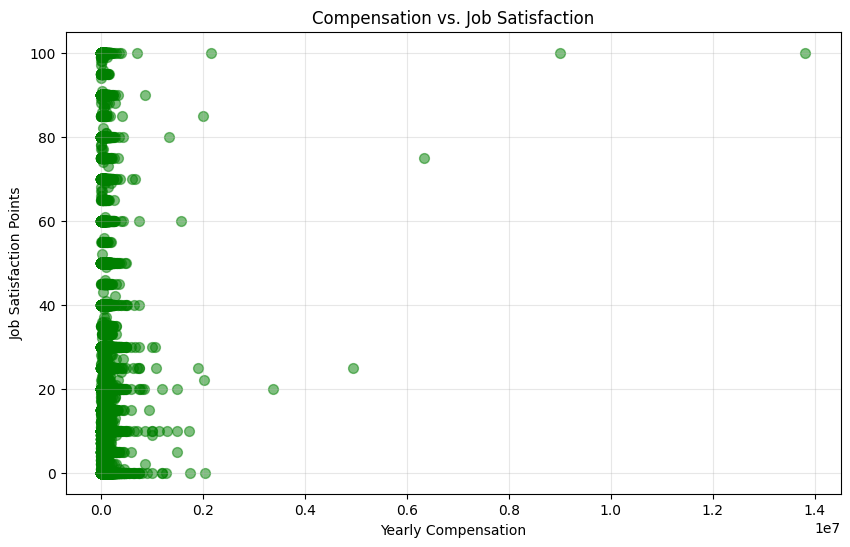

In [4]:
# Clean the data by removing NaN values
df_clean = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Convert compensation to numeric
df_clean['Comp_numeric'] = pd.to_numeric(df_clean['ConvertedCompYearly'], errors='coerce')
df_clean = df_clean.dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Comp_numeric'], df_clean['JobSatPoints_6'], alpha=0.5, s=50, color='green')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction Points')
plt.title('Compensation vs. Job Satisfaction')
plt.grid(True, alpha=0.3)
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


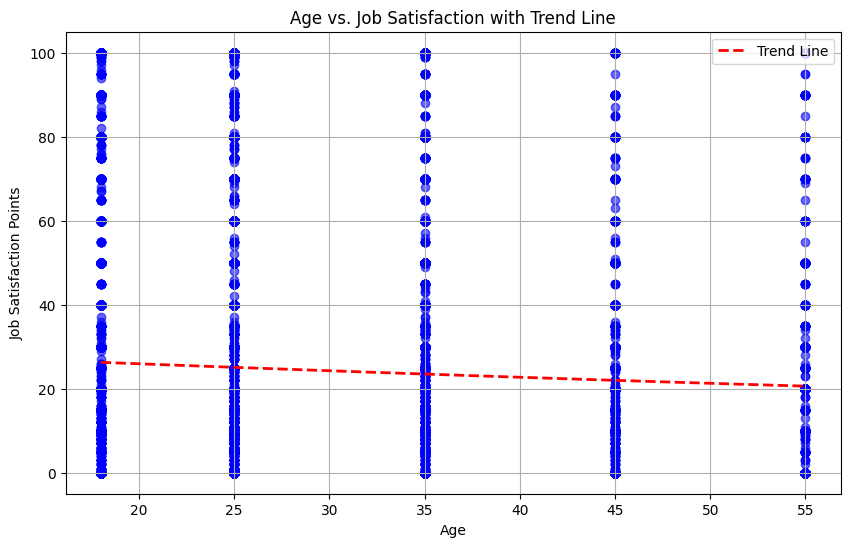

In [5]:
# Clean the data
df_clean = df[['Age', 'JobSatPoints_6']].dropna()

# Parse age values
def parse_age_inline(age_str):
    age_str = str(age_str).strip()
    if 'years old' in age_str:
        import re
        matches = re.findall(r'\d+', age_str)
        if matches:
            return float(matches[0])
    try:
        return float(age_str)
    except:
        return None

df_clean['Age_numeric'] = df_clean['Age'].apply(parse_age_inline)
df_clean = df_clean.dropna()

# Create scatter plot with trend line
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Age_numeric'], df_clean['JobSatPoints_6'], alpha=0.6, color='blue')

# Add trend line
z = np.polyfit(df_clean['Age_numeric'], df_clean['JobSatPoints_6'], 2)
p = np.poly1d(z)
x_trend = np.linspace(df_clean['Age_numeric'].min(), df_clean['Age_numeric'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend Line')

plt.xlabel('Age')
plt.ylabel('Job Satisfaction Points')
plt.title('Age vs. Job Satisfaction with Trend Line')
plt.legend()
plt.grid(True)
plt.show()


#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


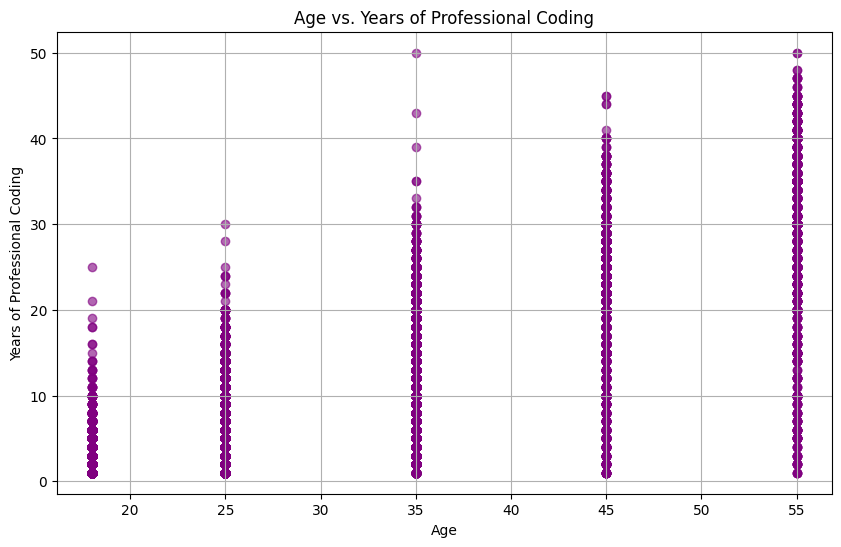

In [6]:
# Clean the data
df_clean = df[['Age', 'YearsCodePro']].dropna()

# Parse age values
def parse_age_inline(age_str):
    age_str = str(age_str).strip()
    if 'years old' in age_str:
        import re
        matches = re.findall(r'\d+', age_str)
        if matches:
            return float(matches[0])
    try:
        return float(age_str)
    except:
        return None

df_clean['Age_numeric'] = df_clean['Age'].apply(parse_age_inline)
df_clean['Years_numeric'] = pd.to_numeric(df_clean['YearsCodePro'], errors='coerce')
df_clean = df_clean.dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Age_numeric'], df_clean['Years_numeric'], alpha=0.6, color='purple')
plt.xlabel('Age')
plt.ylabel('Years of Professional Coding')
plt.title('Age vs. Years of Professional Coding')
plt.grid(True)
plt.show()


### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


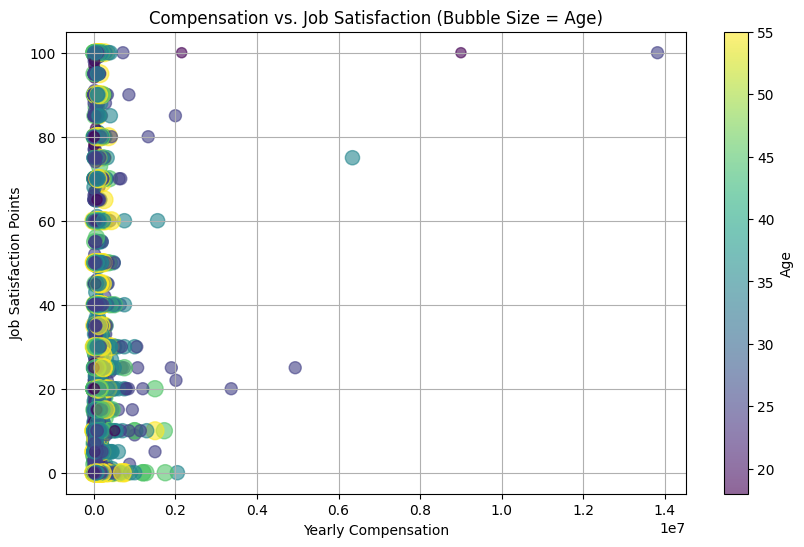

In [7]:
# Clean the data
df_clean = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']].dropna()
df_clean['Comp_numeric'] = pd.to_numeric(df_clean['ConvertedCompYearly'], errors='coerce')

# Parse age values
def parse_age_inline(age_str):
    age_str = str(age_str).strip()
    if 'years old' in age_str:
        import re
        matches = re.findall(r'\d+', age_str)
        if matches:
            return float(matches[0])
    try:
        return float(age_str)
    except:
        return None

df_clean['Age_numeric'] = df_clean['Age'].apply(parse_age_inline)
df_clean = df_clean.dropna()

# Create bubble plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['Comp_numeric'], df_clean['JobSatPoints_6'], 
                     s=df_clean['Age_numeric']*3, alpha=0.6, c=df_clean['Age_numeric'], 
                     cmap='viridis')
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction Points')
plt.title('Compensation vs. Job Satisfaction (Bubble Size = Age)')
cbar = plt.colorbar(scatter)
cbar.set_label('Age')
plt.grid(True)
plt.show()


#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


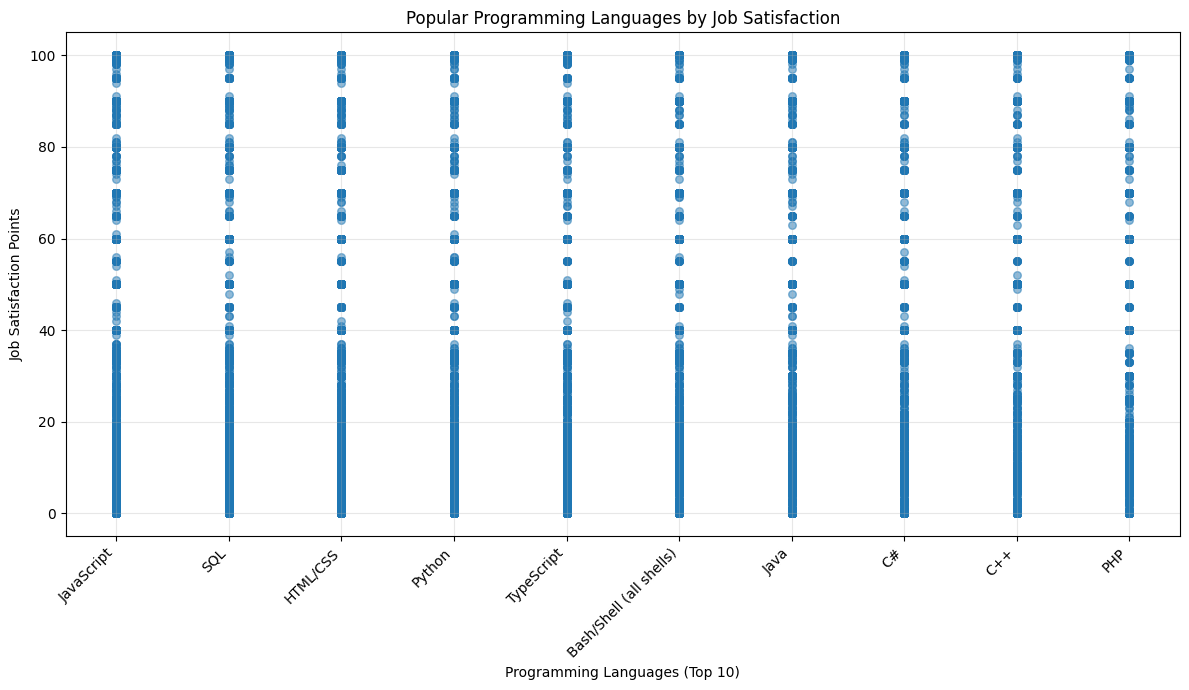

In [8]:
# Clean data and expand languages
df_languages = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()
df_languages = df_languages[df_languages['LanguageHaveWorkedWith'] != '']

# Split languages and create a row for each language
df_expanded = df_languages.assign(LanguageHaveWorkedWith=df_languages['LanguageHaveWorkedWith'].str.split(';')).explode('LanguageHaveWorkedWith')
df_expanded['LanguageHaveWorkedWith'] = df_expanded['LanguageHaveWorkedWith'].str.strip()

# Get top 10 languages
top_languages = df_expanded['LanguageHaveWorkedWith'].value_counts().head(10).index
df_top = df_expanded[df_expanded['LanguageHaveWorkedWith'].isin(top_languages)]

# Create scatter plot
plt.figure(figsize=(12, 7))
languages_encoded = pd.Categorical(df_top['LanguageHaveWorkedWith'], categories=top_languages).codes
plt.scatter(languages_encoded, df_top['JobSatPoints_6'], alpha=0.5, s=30)
plt.xlabel('Programming Languages (Top 10)')
plt.ylabel('Job Satisfaction Points')
plt.title('Popular Programming Languages by Job Satisfaction')
plt.xticks(range(len(top_languages)), top_languages, rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


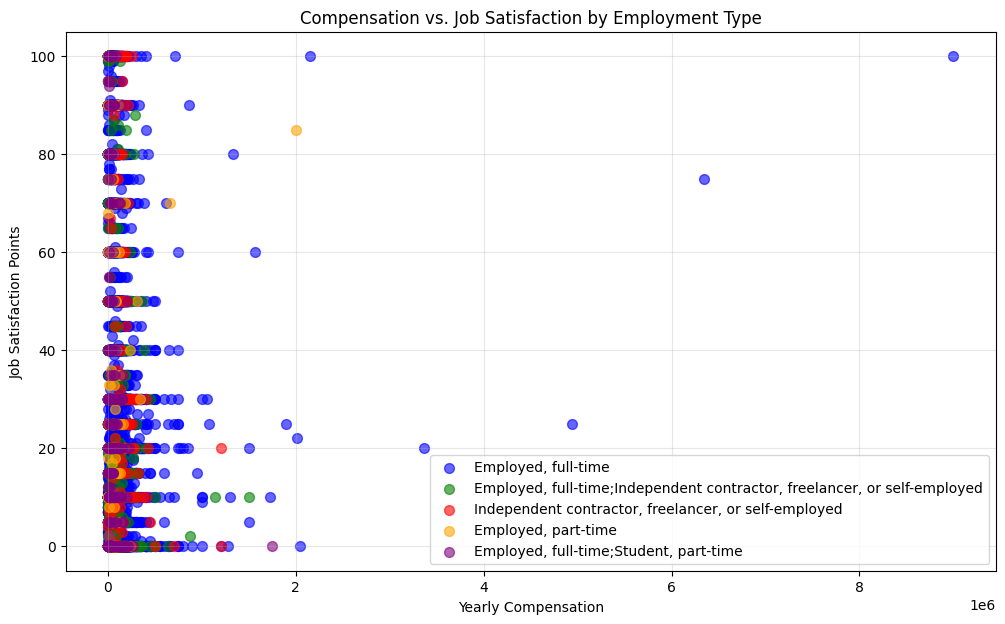

In [9]:
# Clean the data
df_clean = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].dropna()
df_clean['Comp_numeric'] = pd.to_numeric(df_clean['ConvertedCompYearly'], errors='coerce')
df_clean = df_clean.dropna()

# Get top employment types
top_employment = df_clean['Employment'].value_counts().head(5).index

# Create scatter plot with color coding
plt.figure(figsize=(12, 7))
colors = ['blue', 'green', 'red', 'orange', 'purple']
for i, emp_type in enumerate(top_employment):
    mask = df_clean['Employment'] == emp_type
    plt.scatter(df_clean[mask]['Comp_numeric'], df_clean[mask]['JobSatPoints_6'], 
                label=emp_type, alpha=0.6, s=50, color=colors[i % len(colors)])

plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction Points')
plt.title('Compensation vs. Job Satisfaction by Employment Type')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


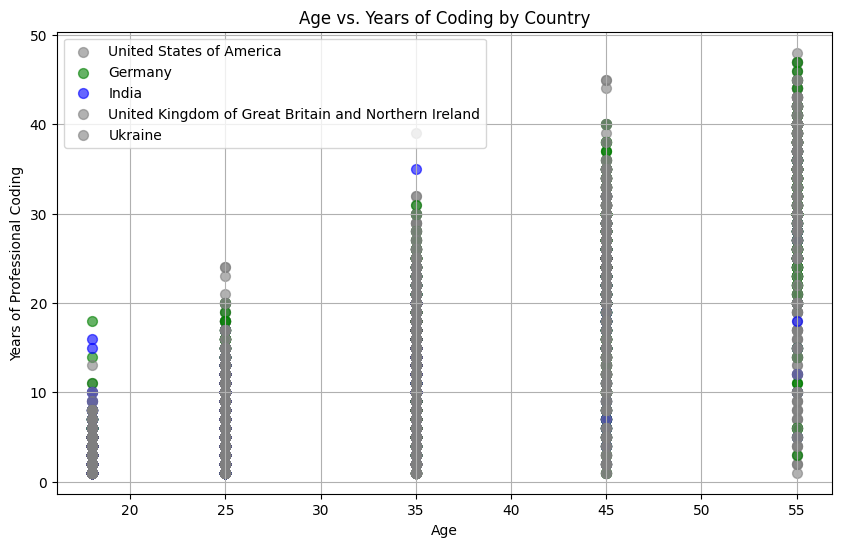

In [10]:
# Clean the data
df_clean = df[['Age', 'YearsCodePro', 'Country']].dropna()

# Parse age values
def parse_age_inline(age_str):
    age_str = str(age_str).strip()
    if 'years old' in age_str:
        import re
        matches = re.findall(r'\d+', age_str)
        if matches:
            return float(matches[0])
    try:
        return float(age_str)
    except:
        return None

df_clean['Age_numeric'] = df_clean['Age'].apply(parse_age_inline)
df_clean['Years_numeric'] = pd.to_numeric(df_clean['YearsCodePro'], errors='coerce')
df_clean = df_clean.dropna()

# Get top 5 countries
top_countries = df_clean['Country'].value_counts().head(5).index
df_clean = df_clean[df_clean['Country'].isin(top_countries)]

# Create scatter plot by country
plt.figure(figsize=(10, 6))
color_map = {'United States': 'red', 'India': 'blue', 'Germany': 'green', 'United Kingdom': 'purple', 'Canada': 'orange'}
for country in top_countries:
    df_country = df_clean[df_clean['Country'] == country]
    plt.scatter(df_country['Age_numeric'], df_country['Years_numeric'], 
               label=country, alpha=0.6, s=50, color=color_map.get(country, 'gray'))

plt.xlabel('Age')
plt.ylabel('Years of Professional Coding')
plt.title('Age vs. Years of Coding by Country')
plt.legend()
plt.grid(True)
plt.show()


### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
